# 06. Interpretabilidade e Validação para o Negócio

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import data_prep, modeling, evaluation, interpretability, visualization

visualization.set_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

In [2]:
import joblib

final_model = joblib.load(MODELS_DIR / "modelo_final.joblib")
final_model_name = (PROCESSED_DIR / "modelo_final_nome.txt").read_text().strip()

X_train, X_test, y_train, y_test = data_prep.load_processed_split()
features = list(X_train.columns)
target = data_prep.TARGET

baseline = modeling.get_baseline()
baseline.fit(X_train, y_train)
baseline_metrics = evaluation.regression_metrics(y_test, baseline.predict(X_test))

final_pred = final_model.predict(X_test)
final_metrics = evaluation.regression_metrics(y_test, final_pred)

print("Modelo final:", final_model_name, "(escolhido pelo RMSE médio de cross-validation, ver notebook 05)")
final_metrics

Modelo final: Ridge (tuned) (escolhido pelo RMSE médio de cross-validation, ver notebook 05)


{'MAE': 288.25673623715903,
 'RMSE': 357.3959786837917,
 'R2': 0.5275961823109607,
 'MAPE': 0.13092617225067085}

## 11. Feature Importance, Permutation e SHAP

Usamos três formas complementares de interpretar o modelo:

- **Importância nativa**: os coeficientes do modelo, se ele for linear, ou o `feature_importances_`, se for baseado em árvore ou boosting. Incluímos também o Random Forest como referência não linear, só para efeito de comparação.
- **Permutation Importance**: uma medida que funciona para qualquer tipo de modelo.
- **SHAP**: a contribuição de cada feature em cada previsão, tanto de forma global quanto local.

Nenhuma dessas medidas deve ser lida como causalidade: elas mostram só associação, capturada pelo modelo.

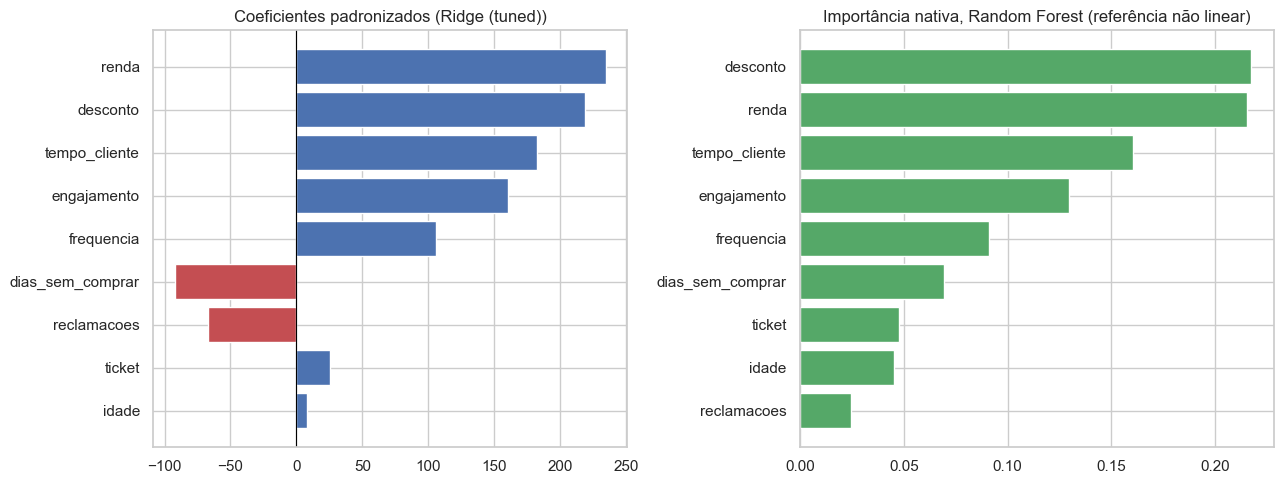

In [3]:
native_imp = interpretability.native_importance(final_model, features)
is_linear = hasattr(final_model.named_steps["model"], "coef_")
native_label = f"{'Coeficientes padronizados' if is_linear else 'Importância nativa'} ({final_model_name})"

rf_reference = modeling.get_models()["RandomForest"]
rf_reference.fit(X_train, y_train)
rf_imp = pd.Series(rf_reference.named_steps["model"].feature_importances_, index=features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_native = ["#4C72B0" if v >= 0 else "#C44E52" for v in native_imp.values]
axes[0].barh(native_imp.index[::-1], native_imp.values[::-1], color=colors_native[::-1])
axes[0].set_title(native_label)
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].barh(rf_imp.index[::-1], rf_imp.values[::-1], color="#55A868")
axes[1].set_title("Importância nativa, Random Forest (referência não linear)")
plt.tight_layout()
plt.show()

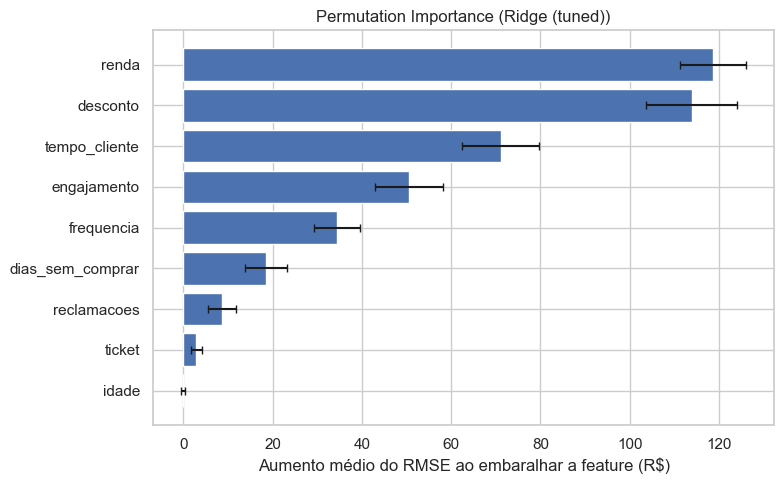

,feature,importancia_media,importancia_std
0,renda,118.678288,7.334251
1,desconto,113.863828,10.115935
2,tempo_cliente,71.123018,8.665012
3,engajamento,50.572760,7.678464
4,frequencia,34.441014,5.115585
5,dias_sem_comprar,18.509442,4.660585
6,reclamacoes,8.665786,3.219549
7,ticket,2.892645,1.223979
8,idade,-0.067750,0.375966


In [4]:
perm_df = interpretability.permutation_importance_df(final_model, X_test, y_test, features)
perm_df.to_csv(PROCESSED_DIR / "permutation_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
order = perm_df.sort_values("importancia_media")
ax.barh(order["feature"], order["importancia_media"], xerr=order["importancia_std"], color="#4C72B0", capsize=3)
ax.set_xlabel("Aumento médio do RMSE ao embaralhar a feature (R$)")
ax.set_title(f"Permutation Importance ({final_model_name})")
plt.tight_layout()
plt.show()

perm_df

Background dataset has 1657 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1657 when initializing the masker.


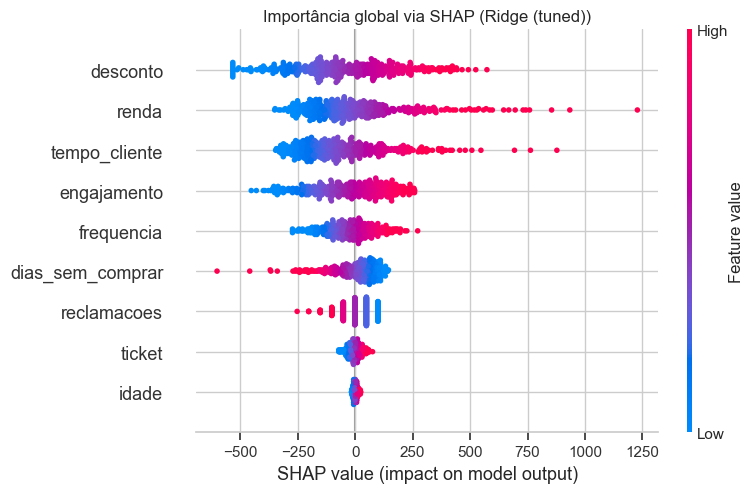

In [5]:
explainer, shap_values = interpretability.shap_explain(final_model, X_train, X_test, features)

import shap
shap.summary_plot(shap_values, features=X_test, feature_names=features, show=False)
plt.title(f"Importância global via SHAP ({final_model_name})")
plt.tight_layout()
plt.show()

### Explicações locais: pior erro vs. acertos típicos

Olhamos tanto o caso de maior erro absoluto (onde o modelo falha) quanto dois casos de **acerto típico** (erro próximo da mediana), para um contraste completo de como o modelo raciocina quando funciona bem e quando falha.

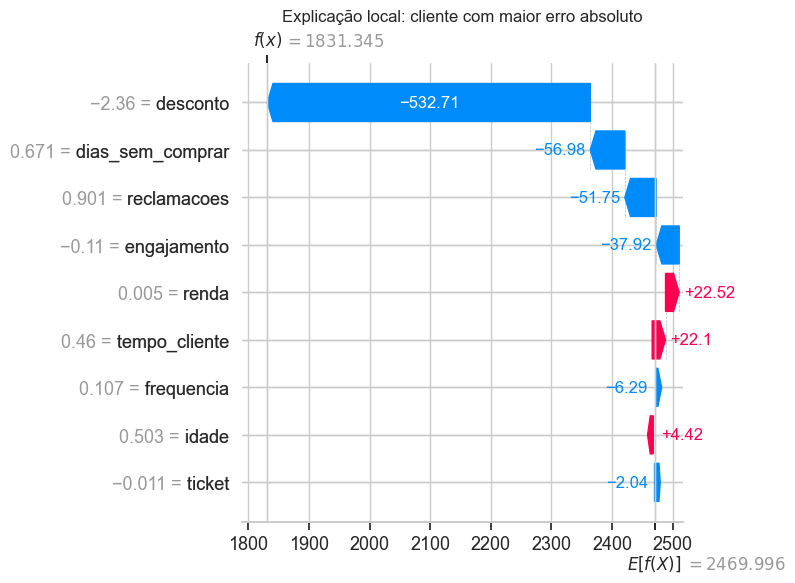

Cliente analisado (features):


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket
293,47.85456,6671.271235,6.286388,8.532074,3,58.049447,47.741417,0.0,178.189155


Real: R$ 3028 | Previsto: R$ 1831 | Erro: R$ 1197


In [6]:
abs_err = np.abs(y_test.values - final_pred)
idx_pior = int(np.argmax(abs_err))
mediana_err = np.median(abs_err)
idx_tipicos = np.argsort(np.abs(abs_err - mediana_err))[:2]  # 2 casos com erro mais perto da mediana

plt.figure()
shap.plots.waterfall(shap_values[idx_pior], show=False)
plt.title("Explicação local: cliente com maior erro absoluto")
plt.tight_layout()
plt.show()

print("Cliente analisado (features):")
display(X_test.iloc[[idx_pior]])
print(f"Real: R$ {y_test.iloc[idx_pior]:.0f} | Previsto: R$ {final_pred[idx_pior]:.0f} | Erro: R$ {abs_err[idx_pior]:.0f}")

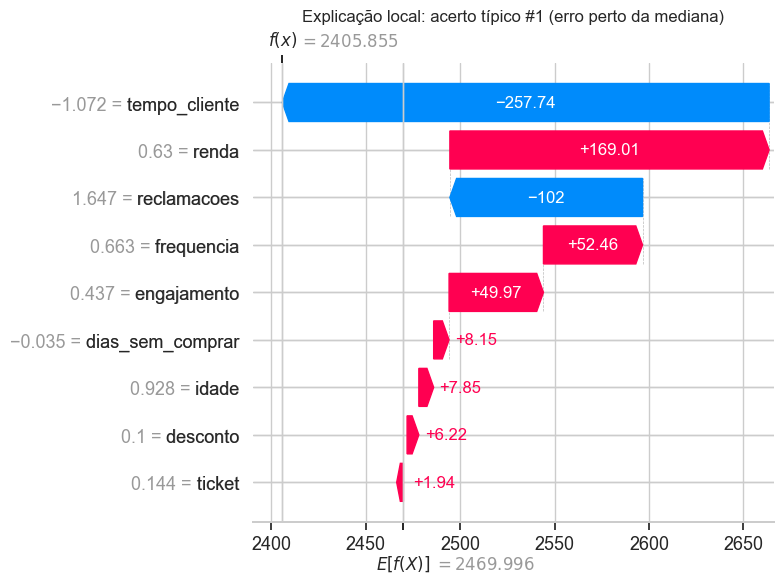

Cliente analisado #1 (features):


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket
410,52.098902,8712.413501,1.886529,10.191564,4,69.140191,33.163719,12.420796,186.649795


Real: R$ 2654 | Previsto: R$ 2406 | Erro: R$ 248



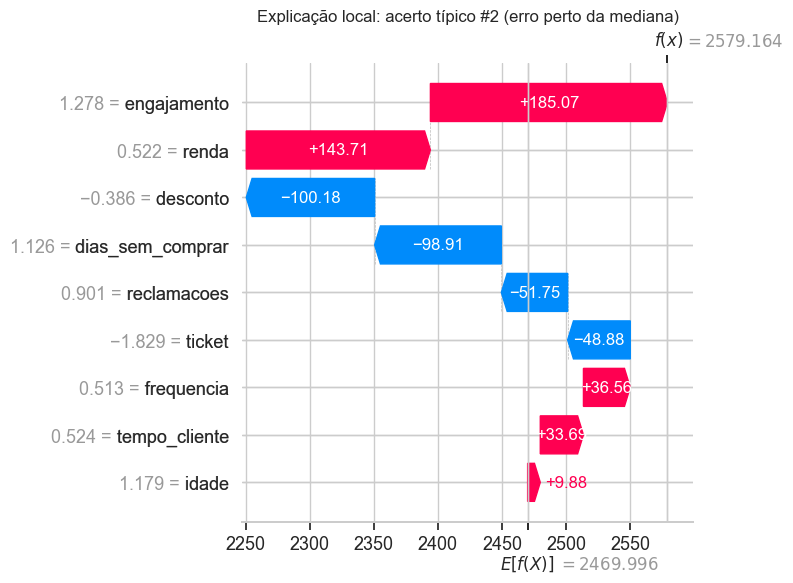

Cliente analisado #2 (features):


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket
326,54.607173,8359.825622,6.468625,9.742635,3,86.189428,57.127748,9.968488,78.598196


Real: R$ 2332 | Previsto: R$ 2579 | Erro: R$ 247



In [7]:
for rank, idx_local in enumerate(idx_tipicos, start=1):
    plt.figure()
    shap.plots.waterfall(shap_values[idx_local], show=False)
    plt.title(f"Explicação local: acerto típico #{rank} (erro perto da mediana)")
    plt.tight_layout()
    plt.show()

    print(f"Cliente analisado #{rank} (features):")
    display(X_test.iloc[[idx_local]])
    print(f"Real: R$ {y_test.iloc[idx_local]:.0f} | Previsto: R$ {final_pred[idx_local]:.0f} | Erro: R$ {abs_err[idx_local]:.0f}\n")

* As três medidas de importância apontam para as mesmas variáveis principais: `renda`, `desconto`, `tempo_cliente` e `engajamento`. Isso indica que o modelo está usando sinais de negócio plausíveis.
* A `idade`, cujo problema de valores implausíveis tratamos no notebook 01, segue com baixa influência no modelo mesmo depois da correção.
* Comparando o pior caso com os acertos típicos, dá para ver que o modelo raciocina de forma consistente, já que as mesmas features dominam a explicação nos dois casos. O erro grande do pior caso parece ser ruído real na target, não um raciocínio incoerente do modelo.

## 12. Robustez por segmento e validação de negócio

In [8]:
seg_renda = evaluation.segment_metrics(y_test, final_pred, X_test["renda"], label="faixa_renda")
seg_renda.to_csv(PROCESSED_DIR / "metrics_por_faixa_renda.csv", index=False)
seg_renda

,faixa_renda,n,MAE,RMSE,MAPE
0,"(1474.738, 4201.634]",104,293.422542,359.857761,0.142327
1,"(4201.634, 5784.094]",104,275.053989,350.654879,0.132498
2,"(5784.094, 7606.146]",103,310.907634,382.745505,0.142782
3,"(7606.146, 23468.803]",104,273.860577,334.899052,0.106212


In [9]:
resid = y_test.values - final_pred
bp = evaluation.breusch_pagan_test(resid, X_test)

print(f"MAE: R$ {final_metrics['MAE']:.1f} ({100*final_metrics['MAE']/y_test.mean():.1f}% do gasto médio)")
print(f"RMSE: R$ {final_metrics['RMSE']:.1f}")
print(f"R²: {final_metrics['R2']:.3f}")
print(f"MAPE: {100*final_metrics['MAPE']:.1f}%")
print(f"Redução de RMSE vs. baseline: {100*(1 - final_metrics['RMSE']/baseline_metrics['RMSE']):.1f}%")
print(f"Breusch-Pagan p-valor: {bp['lm_pvalue']:.3f}")

MAE: R$ 288.3 (12.2% do gasto médio)
RMSE: R$ 357.4
R²: 0.528
MAPE: 13.1%
Redução de RMSE vs. baseline: 31.3%
Breusch-Pagan p-valor: 0.770


**Resumo para o negócio:**

* O modelo final foi escolhido pela evidência mais confiável disponível (RMSE médio de cross-validation, não uma diferença de teste dentro do ruído), supera o baseline com folga e mantém desempenho estável entre folds.
* O erro relativo (MAPE) é um pouco maior para clientes de renda mais baixa (ver notebook 04 e a tabela por faixa de renda acima). É uma limitação que deve ser comunicada junto com qualquer uso do modelo para priorização.
* As variáveis mais importantes, `renda`, `desconto`, `tempo_cliente` e `engajamento`, fazem sentido de negócio e são consistentes entre três métodos de interpretação diferentes.
* Nenhuma dessas relações deve ser lida como causal: o modelo aprende associação estatística, não mecanismo causal. Uma ação de negócio, como aumentar `desconto` para elevar o gasto, precisaria de um teste controlado (A/B) antes de ser adotada, não só da importância da variável no modelo.